# Regularization Methods in Deep Learning: A Hands-On Guide with MNIST

This notebook demonstrates various regularization techniques in deep learning using the MNIST dataset. We will:

1. **Introduce MNIST**: What it is and why we use it.
2. **Import Packages**: Explain each package we need.
3. **Build a Baseline Model**: A simple neural network without regularization.
4. **Apply L2 (Weight Decay) Regularization**
5. **Apply Dropout**
6. **Use Data Augmentation**
7. **Implement Early Stopping**
8. **Compare Results**

Throughout, plots of training vs. validation accuracy and loss will illustrate the effect of each method.

---
## 1. What is MNIST?

The **MNIST** dataset is a collection of handwritten digits (0–9) commonly used to benchmark machine learning algorithms. It contains:

- 60,000 training images
- 10,000 test images
- Each image is 28×28 pixels in grayscale

It’s ideal for beginners because it’s small, well-studied, and easy to visualize.

---

## 2. Importing Packages

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

- **torch**: Core PyTorch library.  
- **torch.nn**: Neural network building blocks.  
- **optim**: Optimization algorithms (SGD, Adam).  
- **DataLoader**, **random_split**: Batch loading and train/val splitting.  
- **torchvision.datasets**: Popular vision datasets like MNIST.  
- **transforms**: Data preprocessing and augmentation.  
- **matplotlib**, **numpy**: Visualization and numeric ops.

## 3. Load and Visualize MNIST

In [3]:
# Transform: convert to tensor and normalize to [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download/train dataset
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split into train (50k) and val (10k)
train_set, val_set = random_split(full_train, [50000, 10000])



PyTorch’s `torchvision.transforms.Compose` is a simple utility for chaining together multiple image transformations. You provide a **list** of individual transforms, and Compose applies them **in order** whenever it processes an image.

For example:
```python
transform = transforms.Compose([
    transforms.ToTensor(),  # convert PIL image/ndarray to tensor and scale pixel values to [0,1]
])
```

- You can later add more transforms inside the list, such as normalization, random cropping, flips, or rotations.  
- Compose ensures each transform is called one after the other on your image data.

```python

The `transforms.ToTensor()` operation in PyTorch does two things:

1. **Converts** a PIL image or NumPy array with pixel values in the range 0–255 (uint8) into a `torch.FloatTensor`.
2. **Scales** these values to the range 0.0–1.0 by dividing every pixel by 255.

This ensures our neural network receives inputs on a consistent, small scale.

```python
transform = transforms.Compose([
    transforms.ToTensor(),  # to tensor and normalize to [0,1]
])

Now let’s **visualize** a few training examples so you can see what the network will learn from.


In [4]:
train_set, val_set = random_split(full_train, [50000, 10000])
# Test set
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
print(f"Training set size: {len(train_set)} samples")
print(f"Validation set size: {len(val_set)} samples")
print(f"Test set size: {len(test_set)} samples")


Training set size: 50000 samples
Validation set size: 10000 samples
Test set size: 10000 samples


In [5]:
# Get one example to show tensor structure
tensor_img, tensor_label = train_set[0]
print("Single image tensor shape:", tensor_img.shape)
print("Single image tensor values (partial):", tensor_img.flatten()[:-1])
print("Single label:", tensor_label)

Single image tensor shape: torch.Size([1, 28, 28])
Single image tensor values (partial): tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000,

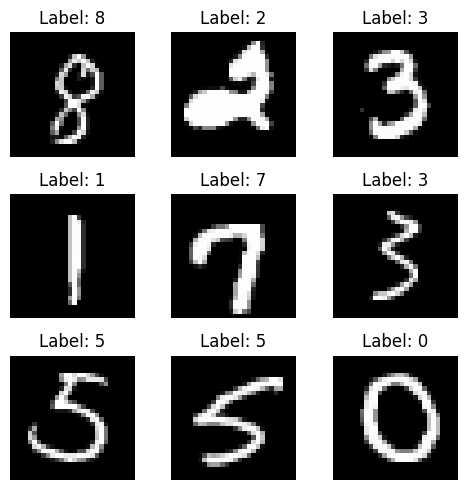

In [10]:
plt.figure(figsize=(5,5))
for i in range(9):
    img, lbl = train_set[i]             # get the i‑th sample
    plt.subplot(3,3,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Label: {lbl}")          # lbl is a scalar, no [i] needed
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Baseline Model (No Regularization)

In this section, we build a simple fully-connected neural network with **no** regularization. This model will serve as our reference to observe overfitting when constraints are absent.

- **Architecture**:
  1. Flatten 28×28 image to a 784-dimensional vector.
  2. Dense layer with 128 neurons and ReLU activation.
  3. Dense layer with 64 neurons and ReLU activation.
  4. Output layer with 10 neurons and softmax (logits for each digit class).

- **Loss**: Cross-entropy.  
- **Optimizer**: Adam with learning rate 0.001.  
- **Metrics**: Training and validation accuracy.


In [ ]:
class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)         # [batch, 1, 28, 28] → [batch, 784]
        x = F.relu(self.fc1(x))     # first hidden layer
        x = F.relu(self.fc2(x))     # second hidden layer
        x = self.fc3(x)             # logits for 10 classes
        return x


In PyTorch, neural network models are defined by creating a Python class that inherits from `torch.nn.Module`:

- **`class BaselineNet(nn.Module):`** tells PyTorch this is a neural network module.
- Inside **`__init__`**, we:
  1. Call `super().__init__()` to initialize the base `Module` functionality.
  2. Define **layers** as member variables (e.g., `self.fc1 = nn.Linear(...)`).
     - These layers are automatically registered and their parameters tracked.
- The **`forward(self, x)`** method defines how input data **flows through** the network:
  1. **Flatten** the input from `[batch, 1, 28, 28]` to `[batch, 784]`.
  2. Apply a **linear transformation** (`fc1`), then a **ReLU** nonlinearity.
  3. Repeat for the second layer (`fc2`).
  4. Produce **logits** by passing through `fc3`.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BaselineNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Explanation of Device, Model, Loss, and Optimizer
- **`nn.CrossEntropyLoss()`** is the standard loss function for multi-class classification; it combines `LogSoftmax` and `NLLLoss` in one.
- **`optim.Adam(model.parameters(), lr=1e-3)`** sets up the Adam optimizer, which adapts learning rates for each parameter and generally converges faster than plain SGD.

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == y).sum().item()
        total += X.size(0)
    return running_loss/total, running_corrects/total

The `train_epoch` function performs one full pass (epoch) of **training** on the model:
1. **`model.train()`**: Sets the model to training mode
2. Initialize accumulators:
   - `running_loss` for summing batch losses.
   - `running_corrects` for counting correct predictions.
   - `total` for total samples seen.
3. **Loop over each batch** `(X, y)` from the DataLoader:
   - Move inputs (`X`) and labels (`y`) to the chosen device (CPU/GPU).
   - **`optimizer.zero_grad()`**: Resets all parameter gradients to zero. PyTorch by default accumulates gradients from previous `backward()` calls, so calling `zero_grad()` ensures you compute fresh gradients for each batch.
   - **`outputs = model(X)`**: Forward pass producing raw scores (logits).
   - **`loss = criterion(outputs, y)`**: Compute loss comparing logits to true labels.
   - **`loss.backward()`**: Backpropagate to compute gradients of all parameters.
   - **`optimizer.step()`**: Update parameters using those gradients.
   - **Accumulate metrics**:
     - `running_loss` adds `loss.item() * batch_size` to track total loss.
     - `preds = outputs.argmax(dim=1)` picks the class with highest score.
     - `running_corrects` adds the number of correct predictions.
     - `total` adds the batch size.
4. After all batches, **return**:
   - **Average loss**: `running_loss/total`.
   - **Accuracy**: `running_corrects/total`.

This structure ensures efficient mini‑batch training and provides per‑epoch metrics for monitoring.

In [ ]:
def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, running_corrects, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            running_loss += loss.item() * X.size(0)
            preds = outputs.argmax(dim=1)
            running_corrects += (preds == y).sum().item()
            total += X.size(0)
    return running_loss/total, running_corrects/total

### Explanation of `eval_epoch`

The `eval_epoch` function runs the model on the validation or test set:

1. **`model.eval()`**: Sets the model to evaluation mode (disables dropout, batch‑norm updates).
2. Initialize accumulators for loss, correct predictions, and sample count.
3. **`with torch.no_grad():`**: Disables gradient computation for efficiency and memory.
4. **Loop over each batch**:
   - Move inputs and labels to the device.
   - Compute `outputs` and `loss`.
   - Accumulate `running_loss` and count correct predictions.
5. **Return** the average loss and accuracy over all samples.

This function is used to monitor the model’s performance on data it hasn’t trained on.

Epoch 1/20 - Train loss: 0.4574, Train acc: 0.8782 - Val loss: 0.2663, Val acc: 0.9161
Epoch 2/20 - Train loss: 0.2033, Train acc: 0.9416 - Val loss: 0.1826, Val acc: 0.9439
Epoch 3/20 - Train loss: 0.1425, Train acc: 0.9576 - Val loss: 0.1418, Val acc: 0.9575
Epoch 4/20 - Train loss: 0.1067, Train acc: 0.9686 - Val loss: 0.1261, Val acc: 0.9610
Epoch 5/20 - Train loss: 0.0856, Train acc: 0.9746 - Val loss: 0.1121, Val acc: 0.9662
Epoch 6/20 - Train loss: 0.0697, Train acc: 0.9787 - Val loss: 0.1167, Val acc: 0.9646
Epoch 7/20 - Train loss: 0.0571, Train acc: 0.9821 - Val loss: 0.1036, Val acc: 0.9693
Epoch 8/20 - Train loss: 0.0468, Train acc: 0.9864 - Val loss: 0.1060, Val acc: 0.9675
Epoch 9/20 - Train loss: 0.0389, Train acc: 0.9881 - Val loss: 0.1056, Val acc: 0.9697
Epoch 10/20 - Train loss: 0.0323, Train acc: 0.9903 - Val loss: 0.0968, Val acc: 0.9725
Epoch 11/20 - Train loss: 0.0271, Train acc: 0.9919 - Val loss: 0.1087, Val acc: 0.9706
Epoch 12/20 - Train loss: 0.0229, Train a

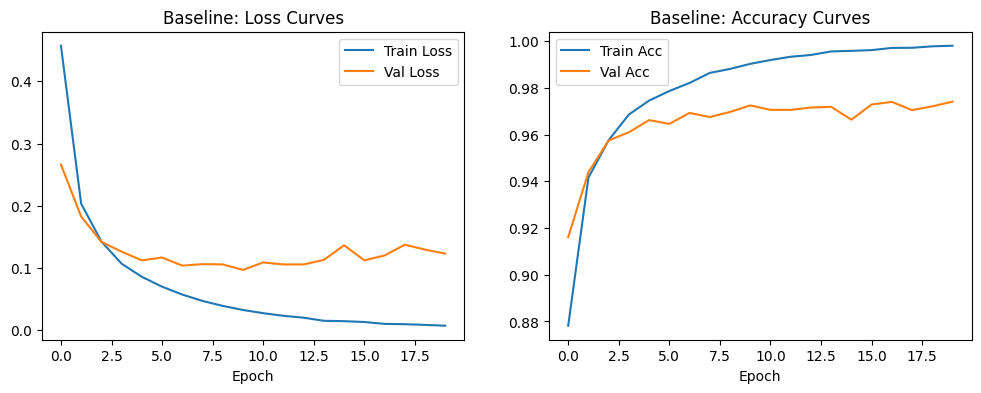

In [ ]:
epochs = 20
batch_size = 128
dtrain = DataLoader(train_set, batch_size=batch_size, shuffle=True)
dval   = DataLoader(val_set,   batch_size=batch_size)
dtest  = DataLoader(test_set,  batch_size=batch_size)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, dtrain, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, dval, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - "
          f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.title('Baseline: Loss Curves')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'],   label='Val Acc')
plt.title('Baseline: Accuracy Curves')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# --- Final evaluation on the TEST set only ---
test_loss, test_acc = eval_epoch(model, dtest, criterion)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")


Final Test Loss: 0.1105
Final Test Accuracy: 0.9763


## 5. L2 Regularization (Weight Decay)

Here we train the same `BaselineNet` but pass `weight_decay` into the optimizer to add an L2 penalty on all weights.

In [ ]:
model_l2 = BaselineNet().to(device)
optimizer_l2 = optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)
criterion    = nn.CrossEntropyLoss()
# Training loop (only track training metrics)
for epoch in range(1, epochs+1):
    tr_loss, tr_acc = train_epoch(model_l2, dtrain, optimizer_l2, criterion)
    print(f"L2 Epoch {epoch}/{epochs} — Train loss: {tr_loss:.4f}, Train acc: {tr_acc:.4f}")

# Final test evaluation
l2_loss, l2_acc = eval_epoch(model_l2, dtest, criterion)
print(f"\nL2 Regularization → Test loss: {l2_loss:.4f}, Test acc: {l2_acc:.4f}")

L2 Epoch 1/20 — Train loss: 0.4509, Train acc: 0.8789
L2 Epoch 2/20 — Train loss: 0.1840, Train acc: 0.9472
L2 Epoch 3/20 — Train loss: 0.1342, Train acc: 0.9606
L2 Epoch 4/20 — Train loss: 0.1047, Train acc: 0.9690
L2 Epoch 5/20 — Train loss: 0.0859, Train acc: 0.9738
L2 Epoch 6/20 — Train loss: 0.0717, Train acc: 0.9781
L2 Epoch 7/20 — Train loss: 0.0593, Train acc: 0.9823
L2 Epoch 8/20 — Train loss: 0.0505, Train acc: 0.9848
L2 Epoch 9/20 — Train loss: 0.0425, Train acc: 0.9875
L2 Epoch 10/20 — Train loss: 0.0372, Train acc: 0.9885
L2 Epoch 11/20 — Train loss: 0.0308, Train acc: 0.9911
L2 Epoch 12/20 — Train loss: 0.0300, Train acc: 0.9910
L2 Epoch 13/20 — Train loss: 0.0269, Train acc: 0.9919
L2 Epoch 14/20 — Train loss: 0.0215, Train acc: 0.9940
L2 Epoch 15/20 — Train loss: 0.0197, Train acc: 0.9941
L2 Epoch 16/20 — Train loss: 0.0197, Train acc: 0.9940
L2 Epoch 17/20 — Train loss: 0.0173, Train acc: 0.9947
L2 Epoch 18/20 — Train loss: 0.0169, Train acc: 0.9949
L2 Epoch 19/20 — Tr

## 6. L1 Regularization

Because PyTorch doesn’t support L1 weight decay natively, we manually add the L1 norm of all parameters to the loss.

In [ ]:
model_l1   = BaselineNet().to(device)
optimizer_l1 = optim.Adam(model_l1.parameters(), lr=1e-3)
l1_lambda  = 1e-5
criterion  = nn.CrossEntropyLoss()

for epoch in range(1, epochs+1):
    model_l1.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for X, y in dtrain:
        X, y = X.to(device), y.to(device)
        optimizer_l1.zero_grad()
        outputs = model_l1(X)
        loss = criterion(outputs, y)

        # add L1 penalty
        l1_norm = sum(p.abs().sum() for p in model_l1.parameters())
        loss = loss + l1_lambda * l1_norm

        loss.backward()
        optimizer_l1.step()

        running_loss += loss.item() * X.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == y).sum().item()
        total += X.size(0)

    print(f"L1 Epoch {epoch}/{epochs} — Train loss: {running_loss/total:.4f}, Train acc: {running_corrects/total:.4f}")

l1_loss, l1_acc = eval_epoch(model_l1, dtest, criterion)
print(f"\nL1 Regularization → Test loss: {l1_loss:.4f}, Test acc: {l1_acc:.4f}")

L1 Epoch 1/20 — Train loss: 0.4891, Train acc: 0.8757
L1 Epoch 2/20 — Train loss: 0.2370, Train acc: 0.9410
L1 Epoch 3/20 — Train loss: 0.1836, Train acc: 0.9554
L1 Epoch 4/20 — Train loss: 0.1506, Train acc: 0.9653
L1 Epoch 5/20 — Train loss: 0.1262, Train acc: 0.9725
L1 Epoch 6/20 — Train loss: 0.1122, Train acc: 0.9762
L1 Epoch 7/20 — Train loss: 0.1000, Train acc: 0.9800
L1 Epoch 8/20 — Train loss: 0.0903, Train acc: 0.9830
L1 Epoch 9/20 — Train loss: 0.0829, Train acc: 0.9858
L1 Epoch 10/20 — Train loss: 0.0764, Train acc: 0.9876
L1 Epoch 11/20 — Train loss: 0.0700, Train acc: 0.9898
L1 Epoch 12/20 — Train loss: 0.0669, Train acc: 0.9909
L1 Epoch 13/20 — Train loss: 0.0633, Train acc: 0.9919
L1 Epoch 14/20 — Train loss: 0.0606, Train acc: 0.9925
L1 Epoch 15/20 — Train loss: 0.0596, Train acc: 0.9931
L1 Epoch 16/20 — Train loss: 0.0559, Train acc: 0.9944
L1 Epoch 17/20 — Train loss: 0.0534, Train acc: 0.9950
L1 Epoch 18/20 — Train loss: 0.0522, Train acc: 0.9954
L1 Epoch 19/20 — Tr

## 7. Dropout

We define a new network class that inserts `nn.Dropout` layers between the dense layers.

In [ ]:
class DropoutNet(nn.Module):
    def __init__(self, drop_rate=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(28*28, 128)
        self.drop1   = nn.Dropout(drop_rate)
        self.fc2     = nn.Linear(128, 64)
        self.drop2   = nn.Dropout(drop_rate)
        self.fc3     = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        return self.fc3(x)


model_do    = DropoutNet(0.5).to(device)
optimizer_do = optim.Adam(model_do.parameters(), lr=1e-3)
criterion    = nn.CrossEntropyLoss()

for epoch in range(1, epochs+1):
    tr_loss, tr_acc = train_epoch(model_do, dtrain, optimizer_do, criterion)
    print(f"Dropout Epoch {epoch}/{epochs} — Train loss: {tr_loss:.4f}, Train acc: {tr_acc:.4f}")

do_loss, do_acc = eval_epoch(model_do, dtest, criterion)
print(f"\nDropout → Test loss: {do_loss:.4f}, Test acc: {do_acc:.4f}")

Dropout Epoch 1/20 — Train loss: 0.7531, Train acc: 0.7683
Dropout Epoch 2/20 — Train loss: 0.3689, Train acc: 0.8952
Dropout Epoch 3/20 — Train loss: 0.3039, Train acc: 0.9138
Dropout Epoch 4/20 — Train loss: 0.2627, Train acc: 0.9257
Dropout Epoch 5/20 — Train loss: 0.2441, Train acc: 0.9320
Dropout Epoch 6/20 — Train loss: 0.2232, Train acc: 0.9360
Dropout Epoch 7/20 — Train loss: 0.2083, Train acc: 0.9415
Dropout Epoch 8/20 — Train loss: 0.1990, Train acc: 0.9447
Dropout Epoch 9/20 — Train loss: 0.1902, Train acc: 0.9464
Dropout Epoch 10/20 — Train loss: 0.1779, Train acc: 0.9490
Dropout Epoch 11/20 — Train loss: 0.1740, Train acc: 0.9500
Dropout Epoch 12/20 — Train loss: 0.1689, Train acc: 0.9505
Dropout Epoch 13/20 — Train loss: 0.1668, Train acc: 0.9525
Dropout Epoch 14/20 — Train loss: 0.1576, Train acc: 0.9553
Dropout Epoch 15/20 — Train loss: 0.1518, Train acc: 0.9551
Dropout Epoch 16/20 — Train loss: 0.1512, Train acc: 0.9560
Dropout Epoch 17/20 — Train loss: 0.1475, Train a

Below is the dropout training snippet:

```python
# Define and move the dropout model to device
model_do    = DropoutNet(0.5).to(device)


## 8. Early Stopping

We track the validation loss and stop training if it hasn’t improved for `patience` epochs, then load the best model for a final test evaluation.

In [ ]:
patience       = 3
best_val_loss  = float('inf')
epochs_es      = 50
model_es       = BaselineNet().to(device)
optimizer_es   = optim.Adam(model_es.parameters(), lr=1e-3)
criterion      = nn.CrossEntropyLoss()

for epoch in range(1, epochs_es+1):
    tr_loss, tr_acc = train_epoch(model_es, dtrain, optimizer_es, criterion)
    val_loss, val_acc = eval_epoch( model_es, dval, criterion)

    print(f"ES Epoch {epoch}/{epochs_es} — Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_es.state_dict(), 'best_es_model.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load the best weights and test
model_es.load_state_dict(torch.load('best_es_model.pt'))
es_loss, es_acc = eval_epoch(model_es, dtest, criterion)
print(f"\nEarly Stopping → Test loss: {es_loss:.4f}, Test acc: {es_acc:.4f}")

ES Epoch 1/50 — Val loss: 0.2452, Val acc: 0.9282
ES Epoch 2/50 — Val loss: 0.1733, Val acc: 0.9493
ES Epoch 3/50 — Val loss: 0.1414, Val acc: 0.9578
ES Epoch 4/50 — Val loss: 0.1262, Val acc: 0.9615
ES Epoch 5/50 — Val loss: 0.1080, Val acc: 0.9668
ES Epoch 6/50 — Val loss: 0.1075, Val acc: 0.9672
ES Epoch 7/50 — Val loss: 0.1126, Val acc: 0.9678
ES Epoch 8/50 — Val loss: 0.0991, Val acc: 0.9708
ES Epoch 9/50 — Val loss: 0.1000, Val acc: 0.9705
ES Epoch 10/50 — Val loss: 0.1122, Val acc: 0.9684
ES Epoch 11/50 — Val loss: 0.1004, Val acc: 0.9719
Early stopping at epoch 11

Early Stopping → Test loss: 0.0830, Test acc: 0.9750
